In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import HillClimbSearch, ExpertKnowledge, BayesianEstimator

# ── BN Graph Visualizations ──────────────────────────────────────
# Two BNs selected for visualization:
# 1. MH Tech — restricted BN (best individual-level causal structure)
# 2. WHR Gallup — restricted BN (best macro-level causal structure)
# These two are selected because they have the cleanest structures
# and most interpretable causal pathways across all datasets

D:\Diana\Anul III\BachelorArbeit\WellBeingModelling\venv\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


In [4]:
# ── Helper function for drawing BN graphs ───────────────────────

def draw_bn(
    edges,
    target_node,
    title,
    figsize=(14, 9),
    save_path=None,
    highlight_parents=True,
    node_colors=None,
    layout="spring"
):
    """
    Draw a Bayesian Network graph with highlighted target node
    and its direct parents.
    """
    G = nx.DiGraph()
    G.add_edges_from(edges)

    # Layout
    if layout == "spring":
        pos = nx.spring_layout(G, seed=42, k=2.5)
    elif layout == "kamada":
        pos = nx.kamada_kawai_layout(G)
    elif layout == "hierarchical":
        pos = nx.nx_agraph.graphviz_layout(G, prog="dot")

    # Node categories
    parents_of_target = [u for u, v in edges if v == target_node]
    children_of_target = [v for u, v in edges if u == target_node]

    # Default colors if not provided
    if node_colors is None:
        node_colors = {}

    def get_color(node):
        if node in node_colors:
            return node_colors[node]
        if node == target_node:
            return "#E74C3C"      # red — target
        if node in parents_of_target:
            return "#2ECC71"      # green — direct parents
        if node in children_of_target:
            return "#F39C12"      # orange — direct children
        return "#5B9BD5"          # blue — other nodes

    colors = [get_color(n) for n in G.nodes()]
    sizes  = [3000 if n == target_node else
              2200 if n in parents_of_target else
              1800 for n in G.nodes()]

    fig, ax = plt.subplots(figsize=figsize)

    # Draw edges
    nx.draw_networkx_edges(
        G, pos,
        ax=ax,
        arrows=True,
        arrowsize=20,
        arrowstyle="-|>",
        edge_color="#AAAAAA",
        width=1.5,
        connectionstyle="arc3,rad=0.05",
        min_source_margin=25,
        min_target_margin=25,
    )

    # Draw nodes
    nx.draw_networkx_nodes(
        G, pos,
        ax=ax,
        node_color=colors,
        node_size=sizes,
        alpha=0.92
    )

    # Draw labels — shorten long names
    labels = {n: n.replace("_", "\n") for n in G.nodes()}
    nx.draw_networkx_labels(
        G, pos,
        labels=labels,
        ax=ax,
        font_size=7,
        font_color="white",
        font_weight="bold"
    )

    # Legend
    legend_elements = [
        mpatches.Patch(color="#E74C3C", label=f"Target: {target_node}"),
        mpatches.Patch(color="#2ECC71", label="Direct parents of target"),
        mpatches.Patch(color="#F39C12", label="Direct children of target"),
        mpatches.Patch(color="#5B9BD5", label="Other nodes"),
    ]
    ax.legend(handles=legend_elements, loc="lower left",
              fontsize=8, framealpha=0.8)

    ax.set_title(title, fontsize=13, pad=15)
    ax.axis("off")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()

In [5]:
# ── BN 1: MH Tech — Restricted BN ───────────────────────────────
# Rebuild restricted BN from saved preprocessed data

import warnings
warnings.filterwarnings("ignore")

df_bn_mhtech = pd.read_csv(
    "../../data/processed/mental_health_tech_clean.csv"
)

# Same preprocessing as BN notebook
for col in df_bn_mhtech.columns:
    df_bn_mhtech[col] = df_bn_mhtech[col].astype("string")

df_bn_mhtech["Age_binned"] = pd.cut(
    pd.to_numeric(df_bn_mhtech["Age"], errors="coerce"),
    bins=[0, 25, 35, 45, 60, 100],
    labels=["18-25", "26-35", "36-45", "46-60", "60+"]
).astype("string")

df_bn_mhtech = df_bn_mhtech.drop(columns=["Age"])
df_bn_model_mhtech = df_bn_mhtech.drop(
    columns=["Country", "state"], errors="ignore"
).copy()

# Reproduce forbidden edges from BN notebook
forbidden_mhtech = [
    ("treatment", "Age_binned"),
    ("treatment", "Gender"),
    ("treatment", "family_history"),
    ("work_interfere", "Age_binned"),
    ("work_interfere", "Gender"),
    ("work_interfere", "family_history"),
    ("treatment", "benefits"),
    ("treatment", "seek_help"),
    ("treatment", "wellness_program"),
    ("work_interfere", "benefits"),
    ("work_interfere", "seek_help"),
    ("work_interfere", "wellness_program"),
]

ek_mhtech = ExpertKnowledge(forbidden_edges=forbidden_mhtech)
hc_mhtech = HillClimbSearch(df_bn_model_mhtech)

dag_mhtech = hc_mhtech.estimate(
    scoring_method="bic-d",
    expert_knowledge=ek_mhtech,
    max_indegree=3,
    show_progress=False
)

print(f"MH Tech restricted BN — edges: {len(dag_mhtech.edges())}")
print(sorted(dag_mhtech.edges()))

MH Tech restricted BN — edges: 42
[('Gender', 'Age_binned'), ('Gender', 'anonymity'), ('Gender', 'benefits'), ('Gender', 'family_history'), ('Gender', 'leave'), ('Gender', 'no_employees'), ('Gender', 'obs_consequence'), ('Gender', 'seek_help'), ('Gender', 'supervisor'), ('Gender', 'tech_company'), ('Gender', 'treatment'), ('Gender', 'wellness_program'), ('Gender', 'work_interfere'), ('anonymity', 'care_options'), ('benefits', 'seek_help'), ('care_options', 'benefits'), ('family_history', 'work_interfere'), ('mental_health_consequence', 'mental_health_interview'), ('mental_health_consequence', 'mental_vs_physical'), ('mental_health_consequence', 'phys_health_consequence'), ('mental_health_interview', 'phys_health_interview'), ('no_employees', 'self_employed'), ('seek_help', 'wellness_program'), ('self_employed', 'benefits'), ('self_employed', 'remote_work'), ('supervisor', 'coworkers'), ('supervisor', 'mental_health_consequence'), ('work_interfere', 'anonymity'), ('work_interfere', 'car

Saved: ../../outputs/shap/bn_graph_mhtech_full.png


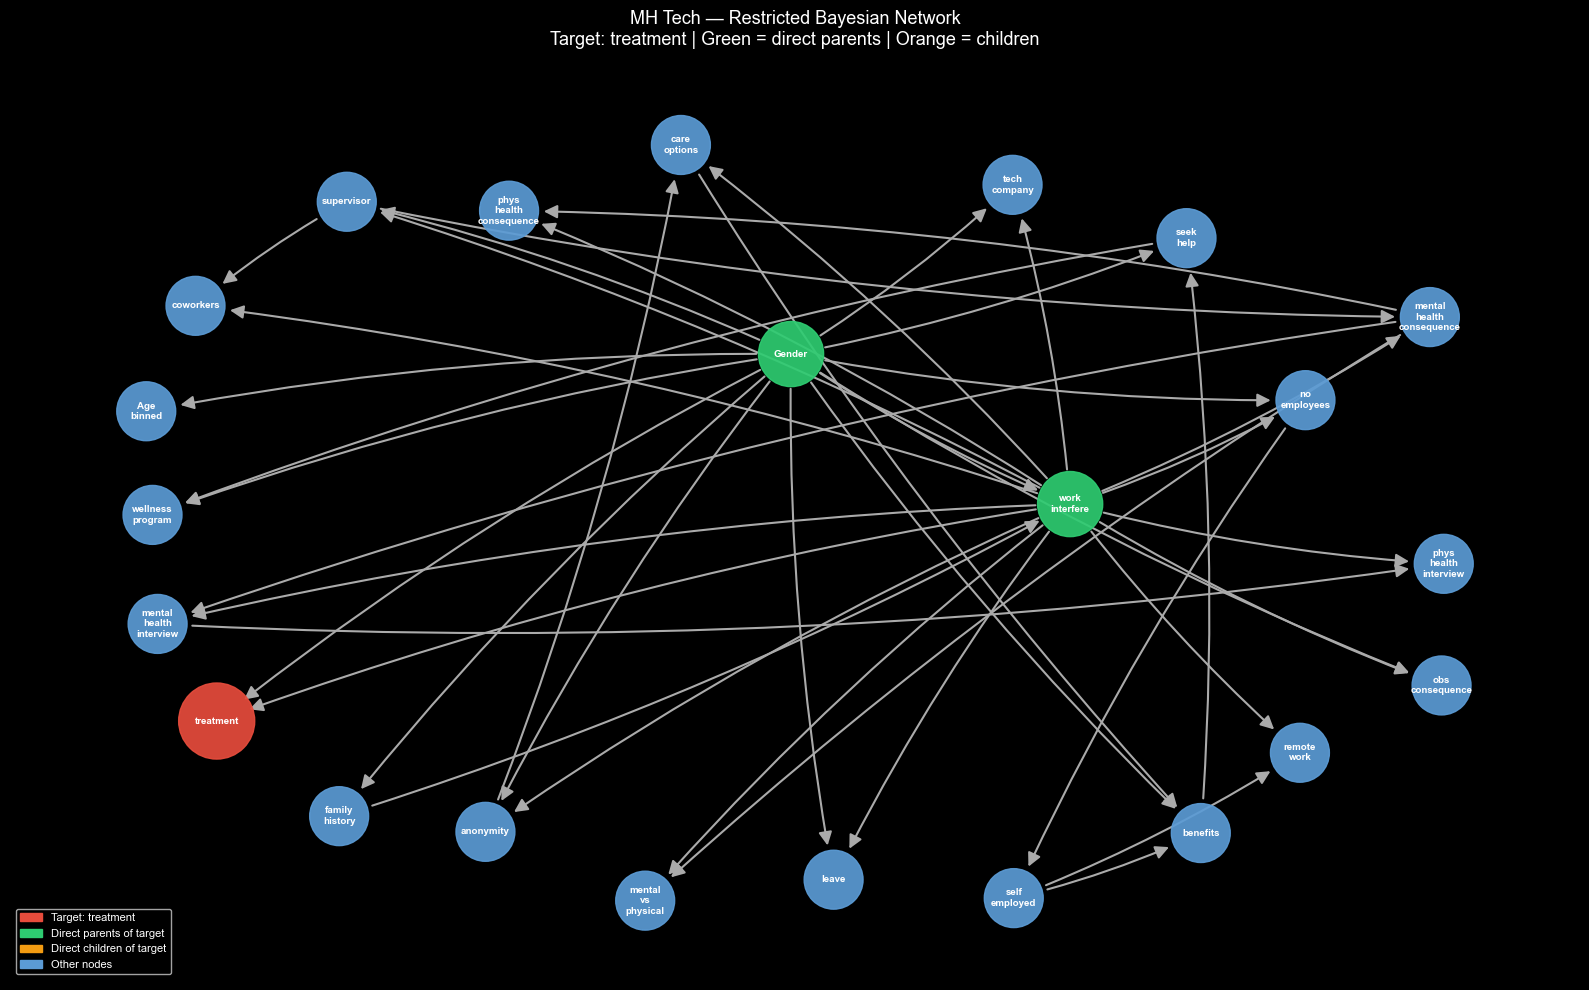

In [6]:
# Draw MH Tech restricted BN — full graph
draw_bn(
    edges=list(dag_mhtech.edges()),
    target_node="treatment",
    title="MH Tech — Restricted Bayesian Network\n"
          "Target: treatment | Green = direct parents | Orange = children",
    figsize=(16, 10),
    save_path="../../outputs/shap/bn_graph_mhtech_full.png",
    layout="spring"
)

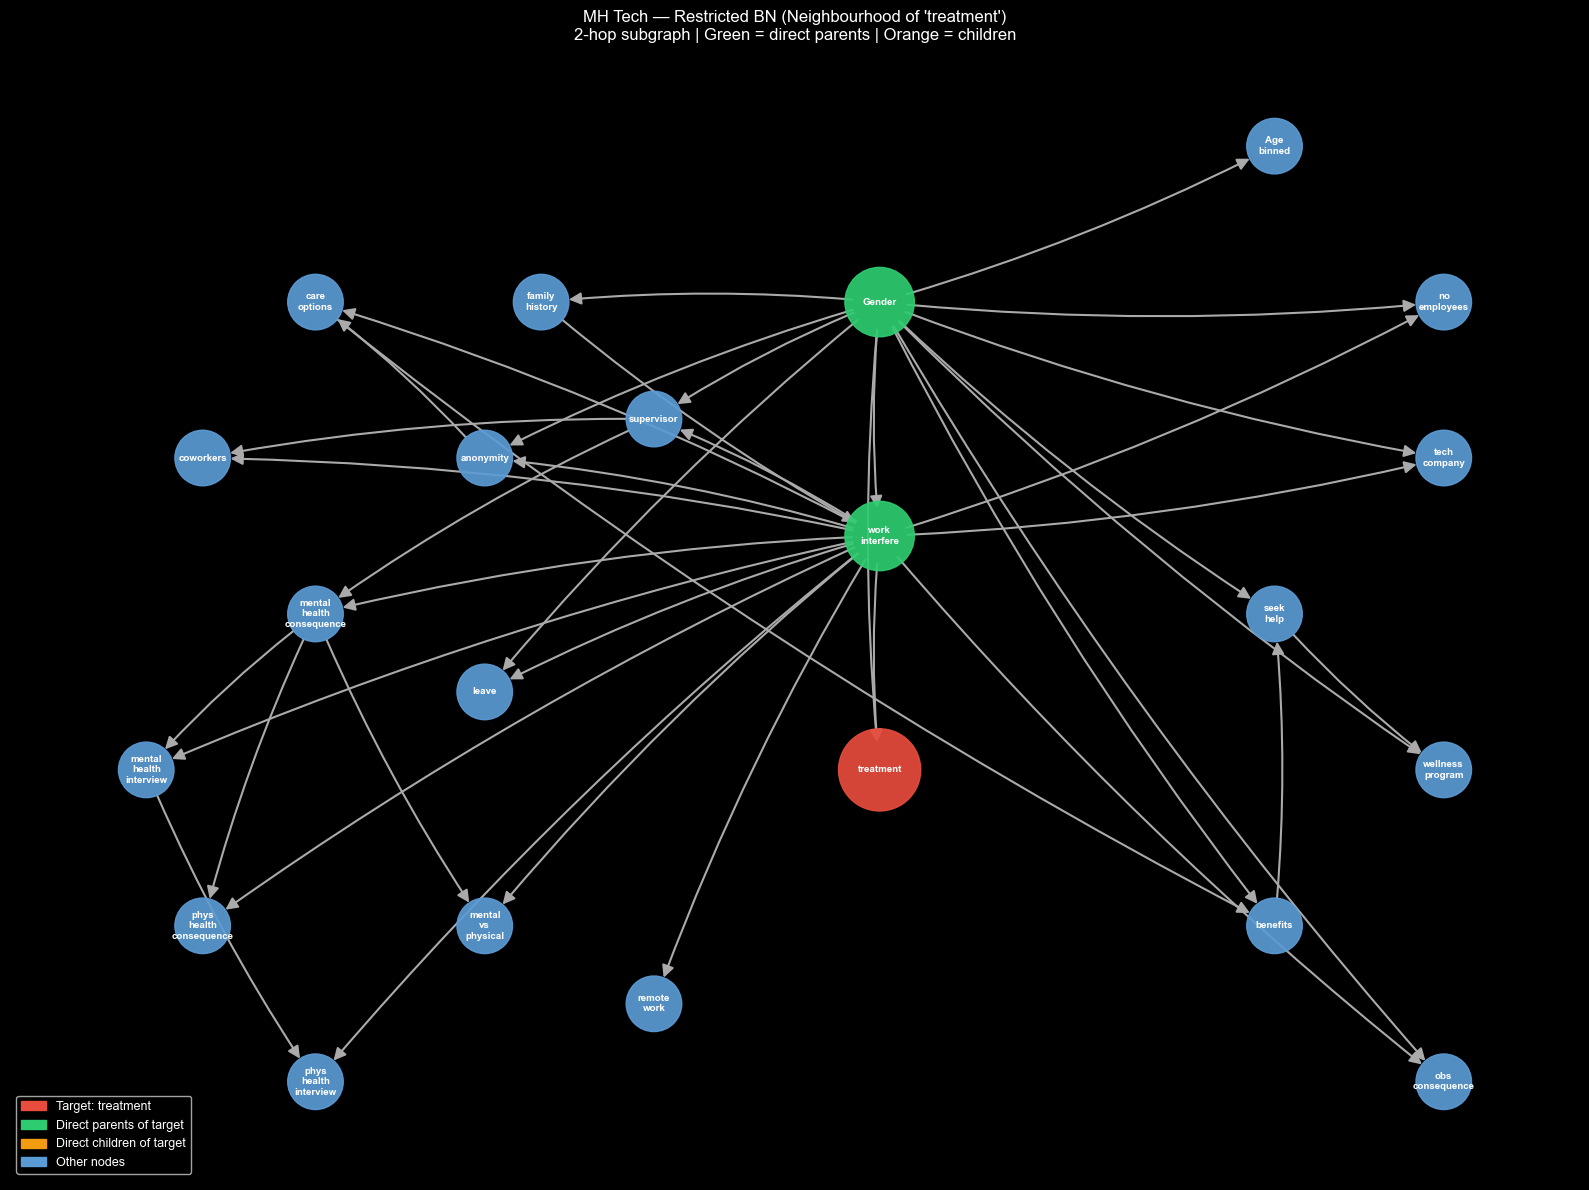

Saved: bn_graph_mhtech_subgraph_v2.png


In [11]:
# ── MH Tech subgraph — manual positions ─────────────────────────

mhtech_subgraph_edges = [
    e for e in dag_mhtech.edges()
    if e[0] in subgraph_nodes and e[1] in subgraph_nodes
]

# Manual positions — spread nodes across a grid
pos_mhtech_manual = {
    # Core pathway — center
    "Gender":               (0.5,  0.7),
    "work_interfere":       (0.5,  0.4),
    "treatment":            (0.5,  0.1),
    "family_history":       (0.2,  0.7),

    # Gender children — right side
    "Age_binned":           (0.85, 0.9),
    "no_employees":         (1.0,  0.7),
    "tech_company":         (1.0,  0.5),
    "seek_help":            (0.85, 0.3),
    "wellness_program":     (1.0,  0.1),
    "benefits":             (0.85, -0.1),
    "obs_consequence":      (1.0,  -0.3),

    # work_interfere children — left side
    "anonymity":            (0.15, 0.5),
    "care_options":         (0.0,  0.7),
    "coworkers":            (-0.1, 0.5),
    "leave":                (0.15, 0.2),
    "mental_health_consequence": (0.0, 0.3),
    "mental_health_interview":   (-0.15, 0.1),
    "mental_vs_physical":        (0.15, -0.1),
    "phys_health_consequence":   (-0.1, -0.1),
    "phys_health_interview":     (0.0,  -0.3),
    "remote_work":               (0.3,  -0.2),
    "supervisor":                (0.3,  0.55),

    # supervisor children
    "mental_health_consequence_child": (0.0, 0.3),
}

# Build subgraph
G_sub2 = nx.DiGraph()
G_sub2.add_edges_from(mhtech_subgraph_edges)

# Only keep nodes that exist in our manual positions
nodes_to_draw = [n for n in G_sub2.nodes() if n in pos_mhtech_manual]
G_sub2 = G_sub2.subgraph(nodes_to_draw).copy()

target = "treatment"
parents_t = [u for u, v in G_sub2.edges() if v == target]
children_t = [v for u, v in G_sub2.edges() if u == target]

def node_color_mh(n):
    if n == target:          return "#E74C3C"
    if n in parents_t:       return "#2ECC71"
    if n in children_t:      return "#F39C12"
    return "#5B9BD5"

colors_mh = [node_color_mh(n) for n in G_sub2.nodes()]
sizes_mh  = [3500 if n == target else
             2500 if n in parents_t else
             1600 for n in G_sub2.nodes()]

fig, ax = plt.subplots(figsize=(16, 12))

nx.draw_networkx_edges(
    G_sub2, pos_mhtech_manual, ax=ax,
    arrows=True, arrowsize=18, arrowstyle="-|>",
    edge_color="#AAAAAA", width=1.5,
    connectionstyle="arc3,rad=0.05",
    min_source_margin=20, min_target_margin=20
)
nx.draw_networkx_nodes(
    G_sub2, pos_mhtech_manual, ax=ax,
    node_color=colors_mh, node_size=sizes_mh, alpha=0.92
)
nx.draw_networkx_labels(
    G_sub2, pos_mhtech_manual, ax=ax,
    labels={n: n.replace("_", "\n") for n in G_sub2.nodes()},
    font_size=7, font_color="white", font_weight="bold"
)

legend_elements = [
    mpatches.Patch(color="#E74C3C", label="Target: treatment"),
    mpatches.Patch(color="#2ECC71", label="Direct parents of target"),
    mpatches.Patch(color="#F39C12", label="Direct children of target"),
    mpatches.Patch(color="#5B9BD5", label="Other nodes"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=9)
ax.set_title(
    "MH Tech — Restricted BN (Neighbourhood of 'treatment')\n"
    "2-hop subgraph | Green = direct parents | Orange = children",
    fontsize=12
)
ax.axis("off")
plt.tight_layout()
plt.savefig("../../outputs/shap/bn_graph_mhtech_subgraph_v2.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: bn_graph_mhtech_subgraph_v2.png")

In [8]:
# ── BN 2: WHR Gallup — Restricted BN ────────────────────────────

df_bn_gallup = pd.read_csv(
    "../../data/processed/world_happiness_gallup_bn_clean.csv"
)

for col in df_bn_gallup.columns:
    df_bn_gallup[col] = df_bn_gallup[col].astype("string")

df_bn_model_gallup = df_bn_gallup.drop(
    columns=["Country_name"], errors="ignore"
).copy()

forbidden_gallup = [
    ("Life_Ladder", "Log_GDP_per_capita"),
    ("Life_Ladder", "Healthy_life_expectancy_at_birth"),
    ("Life_Ladder", "Social_support"),
    ("Life_Ladder", "Freedom_to_make_life_choices"),
    ("Life_Ladder", "Generosity"),
    ("Life_Ladder", "Perceptions_of_corruption"),
    ("Life_Ladder", "Positive_affect"),
    ("Life_Ladder", "Negative_affect"),
    ("Life_Ladder", "Year_bin"),
    ("Log_GDP_per_capita",               "Year_bin"),
    ("Healthy_life_expectancy_at_birth", "Year_bin"),
    ("Social_support",                   "Year_bin"),
    ("Freedom_to_make_life_choices",     "Year_bin"),
    ("Generosity",                       "Year_bin"),
    ("Perceptions_of_corruption",        "Year_bin"),
    ("Positive_affect",                  "Year_bin"),
    ("Negative_affect",                  "Year_bin"),
    ("Positive_affect", "Log_GDP_per_capita"),
    ("Positive_affect", "Healthy_life_expectancy_at_birth"),
    ("Positive_affect", "Social_support"),
    ("Negative_affect", "Log_GDP_per_capita"),
    ("Negative_affect", "Healthy_life_expectancy_at_birth"),
    ("Negative_affect", "Social_support"),
]

ek_gallup = ExpertKnowledge(forbidden_edges=forbidden_gallup)
hc_gallup = HillClimbSearch(df_bn_model_gallup)

dag_gallup = hc_gallup.estimate(
    scoring_method="bic-d",
    expert_knowledge=ek_gallup,
    max_indegree=3,
    show_progress=False
)

print(f"Gallup restricted BN — edges: {len(dag_gallup.edges())}")
print(sorted(dag_gallup.edges()))

Gallup restricted BN — edges: 8
[('Freedom_to_make_life_choices', 'Positive_affect'), ('Generosity', 'Healthy_life_expectancy_at_birth'), ('Healthy_life_expectancy_at_birth', 'Log_GDP_per_capita'), ('Log_GDP_per_capita', 'Life_Ladder'), ('Log_GDP_per_capita', 'Perceptions_of_corruption'), ('Log_GDP_per_capita', 'Social_support'), ('Perceptions_of_corruption', 'Freedom_to_make_life_choices'), ('Perceptions_of_corruption', 'Negative_affect')]


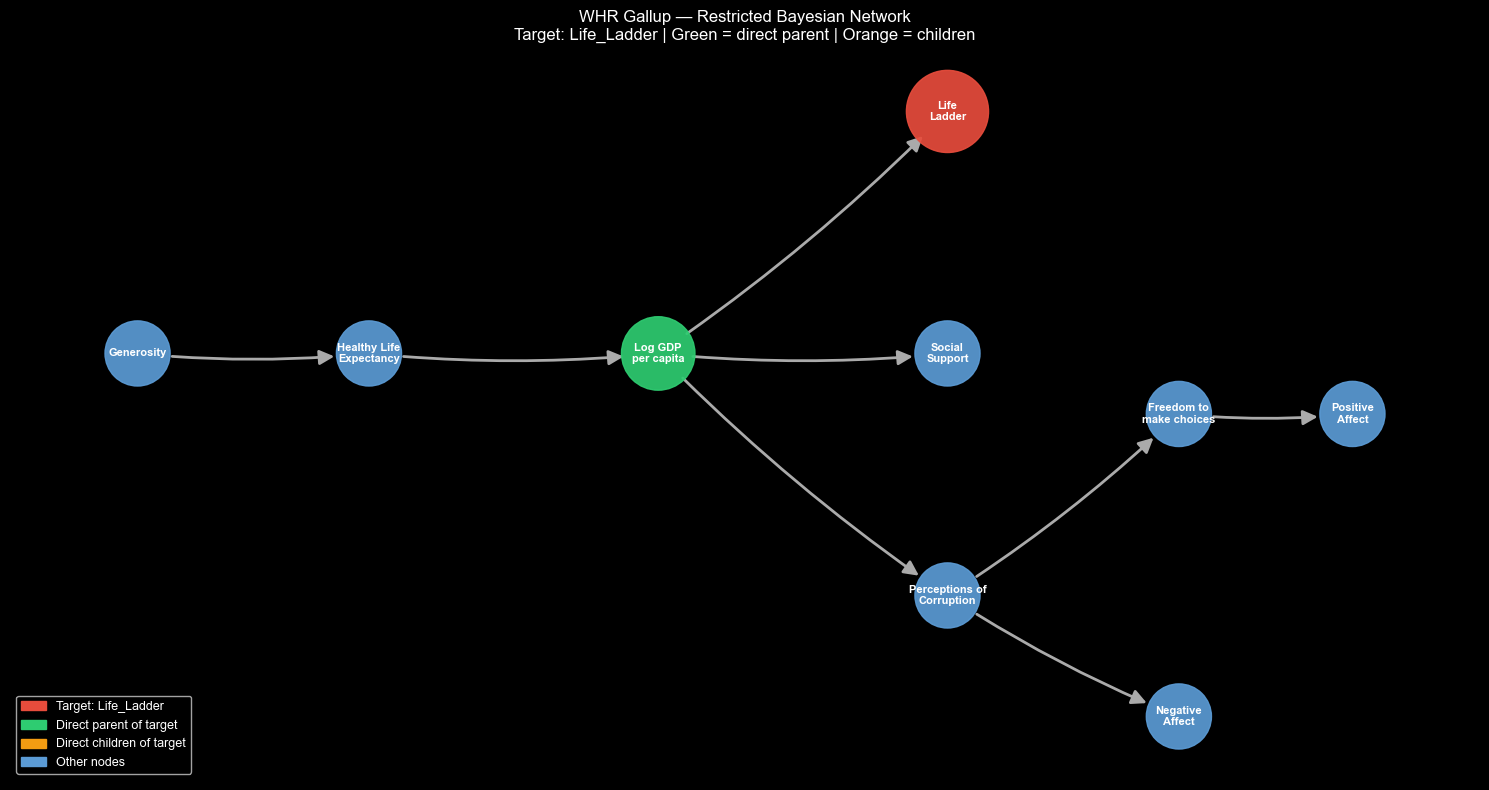

Saved: bn_graph_gallup_full_v2.png


In [12]:
# ── Gallup full graph — manual positions ─────────────────────────

gallup_edges = list(dag_gallup.edges())

# Manual positions — linear causal chain layout
pos_gallup_manual = {
    "Generosity":                        (0.0,  0.5),
    "Healthy_life_expectancy_at_birth":  (0.2,  0.5),
    "Log_GDP_per_capita":                (0.45, 0.5),
    "Life_Ladder":                       (0.7,  0.7),
    "Social_support":                    (0.7,  0.5),
    "Perceptions_of_corruption":         (0.7,  0.3),
    "Freedom_to_make_life_choices":      (0.9,  0.45),
    "Negative_affect":                   (0.9,  0.2),
    "Positive_affect":                   (1.05, 0.45),
}

G_gallup = nx.DiGraph(gallup_edges)

target_g = "Life_Ladder"
parents_g  = [u for u, v in G_gallup.edges() if v == target_g]
children_g = [v for u, v in G_gallup.edges() if u == target_g]

def node_color_g(n):
    if n == target_g:        return "#E74C3C"
    if n in parents_g:       return "#2ECC71"
    if n in children_g:      return "#F39C12"
    return "#5B9BD5"

colors_g = [node_color_g(n) for n in G_gallup.nodes()]
sizes_g  = [3500 if n == target_g else
            2800 if n in parents_g else
            2200 for n in G_gallup.nodes()]

# Shorten labels for display
label_map = {
    "Generosity":                        "Generosity",
    "Healthy_life_expectancy_at_birth":  "Healthy Life\nExpectancy",
    "Log_GDP_per_capita":                "Log GDP\nper capita",
    "Life_Ladder":                       "Life\nLadder",
    "Social_support":                    "Social\nSupport",
    "Perceptions_of_corruption":         "Perceptions of\nCorruption",
    "Freedom_to_make_life_choices":      "Freedom to\nmake choices",
    "Negative_affect":                   "Negative\nAffect",
    "Positive_affect":                   "Positive\nAffect",
}

fig, ax = plt.subplots(figsize=(15, 8))

nx.draw_networkx_edges(
    G_gallup, pos_gallup_manual, ax=ax,
    arrows=True, arrowsize=22, arrowstyle="-|>",
    edge_color="#AAAAAA", width=2.0,
    connectionstyle="arc3,rad=0.05",
    min_source_margin=25, min_target_margin=25
)
nx.draw_networkx_nodes(
    G_gallup, pos_gallup_manual, ax=ax,
    node_color=colors_g, node_size=sizes_g, alpha=0.92
)
nx.draw_networkx_labels(
    G_gallup, pos_gallup_manual, ax=ax,
    labels=label_map,
    font_size=8, font_color="white", font_weight="bold"
)

legend_elements = [
    mpatches.Patch(color="#E74C3C", label="Target: Life_Ladder"),
    mpatches.Patch(color="#2ECC71", label="Direct parent of target"),
    mpatches.Patch(color="#F39C12", label="Direct children of target"),
    mpatches.Patch(color="#5B9BD5", label="Other nodes"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=9)
ax.set_title(
    "WHR Gallup — Restricted Bayesian Network\n"
    "Target: Life_Ladder | Green = direct parent | Orange = children",
    fontsize=12
)
ax.axis("off")
plt.tight_layout()
plt.savefig("../../outputs/shap/bn_graph_gallup_full_v2.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: bn_graph_gallup_full_v2.png")

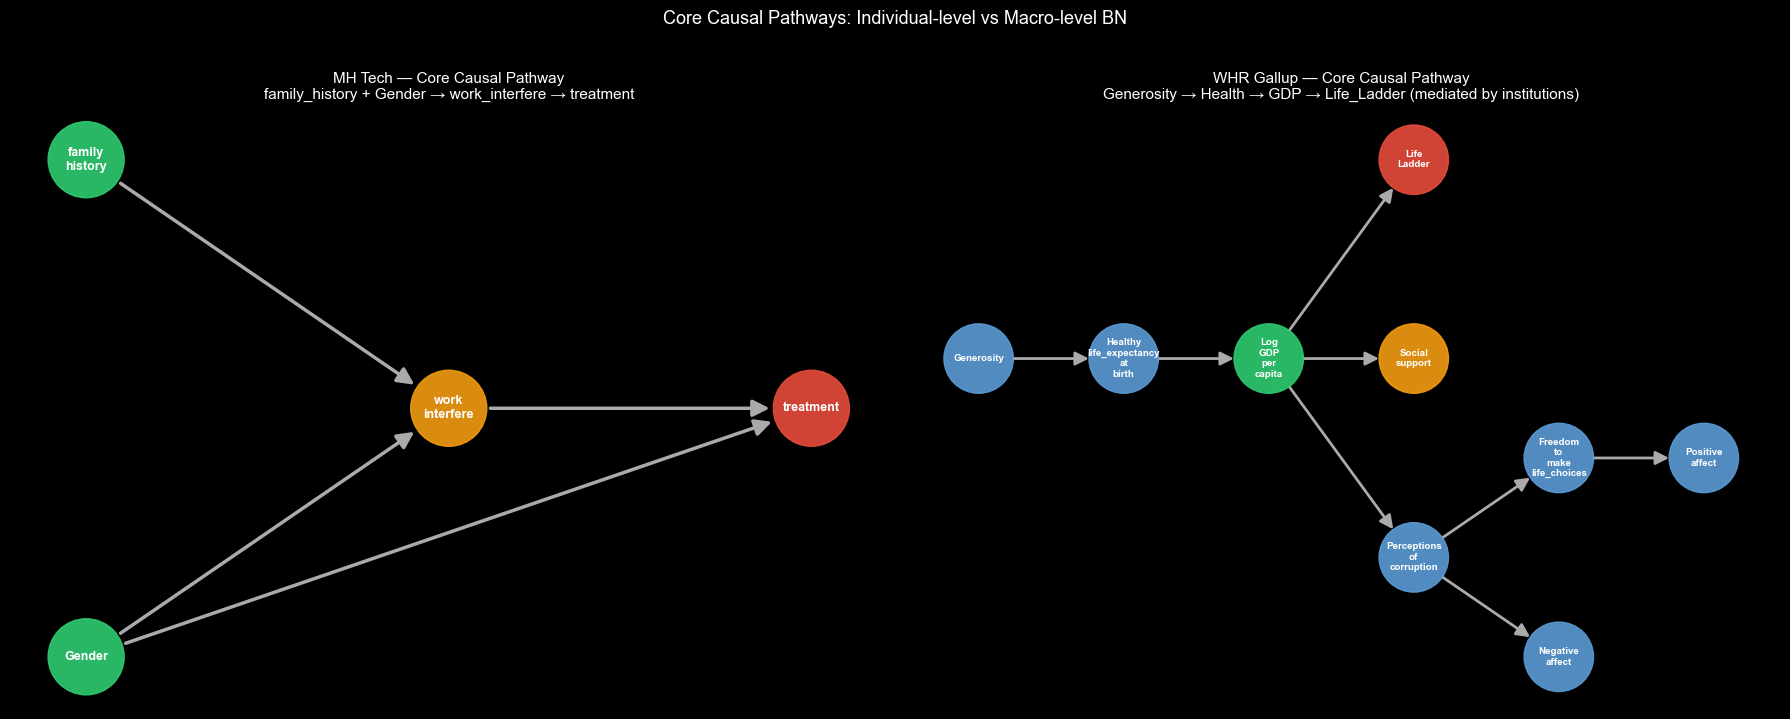

Saved: bn_core_pathways.png


In [10]:
# ── Side-by-side summary of causal pathways ──────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# MH Tech pathway
pathway_mhtech = [
    ("family_history", "work_interfere"),
    ("Gender", "work_interfere"),
    ("Gender", "treatment"),
    ("work_interfere", "treatment"),
]

G_path_mh = nx.DiGraph(pathway_mhtech)
pos_mh = {
    "family_history": (0, 1),
    "Gender":         (0, -1),
    "work_interfere": (1, 0),
    "treatment":      (2, 0),
}

node_colors_mh = {
    "treatment":      "#E74C3C",
    "work_interfere": "#F39C12",
    "family_history": "#2ECC71",
    "Gender":         "#2ECC71",
}

plt.sca(axes[0])
nx.draw_networkx_edges(
    G_path_mh, pos_mh, ax=axes[0],
    arrows=True, arrowsize=25,
    arrowstyle="-|>",
    edge_color="#AAAAAA", width=2.5,
    min_source_margin=30, min_target_margin=30
)
nx.draw_networkx_nodes(
    G_path_mh, pos_mh, ax=axes[0],
    node_color=[node_colors_mh[n] for n in G_path_mh.nodes()],
    node_size=3000, alpha=0.9
)
nx.draw_networkx_labels(
    G_path_mh, pos_mh, ax=axes[0],
    labels={n: n.replace("_", "\n") for n in G_path_mh.nodes()},
    font_size=9, font_color="white", font_weight="bold"
)
axes[0].set_title(
    "MH Tech — Core Causal Pathway\n"
    "family_history + Gender → work_interfere → treatment",
    fontsize=11
)
axes[0].axis("off")

# Gallup pathway
pathway_gallup = [
    ("Generosity",                       "Healthy_life_expectancy_at_birth"),
    ("Healthy_life_expectancy_at_birth", "Log_GDP_per_capita"),
    ("Log_GDP_per_capita",               "Life_Ladder"),
    ("Log_GDP_per_capita",               "Social_support"),
    ("Log_GDP_per_capita",               "Perceptions_of_corruption"),
    ("Perceptions_of_corruption",        "Freedom_to_make_life_choices"),
    ("Perceptions_of_corruption",        "Negative_affect"),
    ("Freedom_to_make_life_choices",     "Positive_affect"),
]

G_path_g = nx.DiGraph(pathway_gallup)
pos_g = {
    "Generosity":                        (-2, 0),
    "Healthy_life_expectancy_at_birth":  (-1, 0),
    "Log_GDP_per_capita":                (0,  0),
    "Life_Ladder":                       (1,  1),
    "Social_support":                    (1,  0),
    "Perceptions_of_corruption":         (1, -1),
    "Freedom_to_make_life_choices":      (2, -0.5),
    "Negative_affect":                   (2, -1.5),
    "Positive_affect":                   (3, -0.5),
}

node_colors_g = {
    "Life_Ladder":                       "#E74C3C",
    "Log_GDP_per_capita":                "#2ECC71",
    "Generosity":                        "#5B9BD5",
    "Healthy_life_expectancy_at_birth":  "#5B9BD5",
    "Social_support":                    "#F39C12",
    "Perceptions_of_corruption":         "#5B9BD5",
    "Freedom_to_make_life_choices":      "#5B9BD5",
    "Negative_affect":                   "#5B9BD5",
    "Positive_affect":                   "#5B9BD5",
}

plt.sca(axes[1])
nx.draw_networkx_edges(
    G_path_g, pos_g, ax=axes[1],
    arrows=True, arrowsize=20,
    arrowstyle="-|>",
    edge_color="#AAAAAA", width=2.0,
    min_source_margin=25, min_target_margin=25
)
nx.draw_networkx_nodes(
    G_path_g, pos_g, ax=axes[1],
    node_color=[node_colors_g[n] for n in G_path_g.nodes()],
    node_size=2500, alpha=0.9
)
nx.draw_networkx_labels(
    G_path_g, pos_g, ax=axes[1],
    labels={n: n.replace("_", "\n").replace("life\n", "life_")
            for n in G_path_g.nodes()},
    font_size=7, font_color="white", font_weight="bold"
)
axes[1].set_title(
    "WHR Gallup — Core Causal Pathway\n"
    "Generosity → Health → GDP → Life_Ladder (mediated by institutions)",
    fontsize=11
)
axes[1].axis("off")

plt.suptitle(
    "Core Causal Pathways: Individual-level vs Macro-level BN",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig("../../outputs/shap/bn_core_pathways.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: bn_core_pathways.png")

In [ ]:
# ## BN Graph Visualizations
#
# ### MH Tech — Restricted BN (2-hop neighbourhood of 'treatment')
#
# The MH Tech graph reveals a hub-and-spoke structure centered on
# two green nodes — Gender and work_interfere — which serve as the
# direct parents of the target node (treatment, red). Gender acts
# as a high-degree hub with outgoing edges to thirteen variables
# including work_interfere, family_history, Age_binned, no_employees,
# tech_company, seek_help, wellness_program, benefits, and
# obs_consequence. This reflects Gender's role as a broad
# sociodemographic stratifier in the workplace mental health context.
#
# work_interfere is the second major hub, with outgoing edges to
# the majority of workplace perception variables: anonymity,
# care_options, coworkers, leave, mental_health_consequence,
# mental_health_interview, mental_vs_physical, phys_health_consequence,
# phys_health_interview, remote_work, and supervisor. This structure
# encodes a plausible causal narrative: work interference acts as a
# central mediating variable that propagates its effects throughout
# the workplace environment, influencing how employees perceive
# mental health consequences, discuss issues with supervisors and
# coworkers, and ultimately whether they seek treatment.
#
# The absence of direct edges from workplace policy variables
# (benefits, seek_help, wellness_program) to treatment — they are
# two hops away via work_interfere — reflects the expert constraints
# and is causally defensible: workplace support policies influence
# treatment indirectly by moderating interference rather than
# directly enabling treatment seeking.
#
# ### WHR Gallup — Restricted BN
#
# The Gallup graph is the clearest and most interpretable structure
# in the entire study. It reveals a clean left-to-right causal
# chain with Log GDP per capita as the central hub:
#
# Generosity → Healthy Life Expectancy → Log GDP per capita →
# Life Ladder (direct), Social Support, Perceptions of Corruption →
# Freedom to make choices → Positive Affect
#                         → Negative Affect
#
# Log GDP per capita has a single direct edge to Life_Ladder (green
# → red), confirming it as the sole direct parent of the target.
# All other influences on happiness are mediated through GDP —
# social support, institutional quality (corruption), and freedom
# to choose. This is consistent with the WHR theoretical framework
# where economic development is the primary enabler of the social
# and institutional conditions that support human flourishing.
#
# The Generosity → Healthy Life Expectancy → GDP pathway is
# particularly interesting — it suggests that societal generosity
# (civic engagement, charitable behaviour) is upstream of health
# outcomes, which in turn enable economic development. This is a
# directional claim that neither correlation analysis nor ML
# feature importance could provide, and represents the unique
# contribution of BN causal structure learning.
#
# ### Micro vs Macro Contrast
#
# Comparing the two graphs visually illustrates the fundamental
# difference between individual and societal level causal structures:
#
# The MH Tech graph is dense and high-dimensional — 23 nodes, 42
# edges, with two major hubs and many parallel pathways. Individual
# wellbeing is influenced by a complex web of demographic,
# workplace, and personal factors with multiple mediating paths.
# No single variable dominates the entire structure.
#
# The Gallup graph is sparse and linear — 9 nodes, 8 edges, with
# a clear main chain and minimal branching. Societal happiness is
# driven by a small number of structural indicators in a relatively
# ordered causal sequence. The structure is clean enough to read
# as a narrative: generosity enables health, health enables
# prosperity, prosperity directly enables happiness and mediates
# institutional quality and social connectedness.
#
# This visual contrast directly supports the thesis argument that
# macro-level wellbeing data has cleaner causal structure than
# micro-level data, and that BN structure learning is more
# reliable and interpretable at the societal level where variables
# are more structurally distinct and less conceptually entangled.